#🟩 PHASE 1 — Environment Setup
🎯 Objective : Prepare the notebook, install all required libraries, and make the experiment reproducible.

In [1]:
# ==========================================================
# Install Required Libraries
# ==========================================================

!pip -q install contractions
!pip -q install vaderSentiment
!pip -q install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [2]:
# ==========================================================
# Import Libraries
# ==========================================================

# Data Handling
import pandas as pd
import numpy as np

# Text Processing
import re
import string
import contractions

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# XGBoost
from xgboost import XGBClassifier

# Sparse Matrix Operations
from scipy.sparse import hstack

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ==========================================================
# Download NLTK Resources
# ==========================================================

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [4]:
# ==========================================================
# Random Seed
# ==========================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Random Seed:", RANDOM_STATE)

Random Seed: 42


In [5]:
# ==========================================================
# Plot Configuration
# ==========================================================

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

plt.rcParams["font.size"] = 12

#🟩 PHASE 2 — Dataset Loading
🎯 Objective : Load datasets-
UCI Drug Review → Large-scale dataset used for annotation, machine learning, and drug–ADE association mining.

In [6]:
# ==========================================================
# Load UCI Drug Review Dataset
# ==========================================================

from datasets import load_dataset

uci_dataset = load_dataset("dd-n-kk/uci-drug-review-cleaned")

README.md:   0%|          | 0.00/600 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 49.5MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.5MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/161297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/53766 [00:00<?, ? examples/s]

In [7]:
# ==========================================================
# Convert to Pandas DataFrames
# ==========================================================

train_df = uci_dataset["train"].to_pandas()

test_df = uci_dataset["test"].to_pandas()

In [8]:
# ==========================================================
# Merge Train and Test
# ==========================================================

uci_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

print("Total Reviews:", len(uci_df))

Total Reviews: 215063


In [9]:
# ==========================================================
# Preview Dataset
# ==========================================================

uci_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


In [10]:
# ==========================================================
# Dataset Information
# ==========================================================

uci_df.info()

# ==========================================================
# Dataset Shape
# ==========================================================

print("Rows :", uci_df.shape[0])
print("Columns :", uci_df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    212357 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 11.5+ MB
Rows : 215063
Columns : 7


In [11]:
# ==========================================================
# Missing Values
# ==========================================================

uci_df.isnull().sum()

,0
uniqueID,0
drugName,0
condition,2706
review,0
rating,0
date,0
usefulCount,0


In [12]:
# ==========================================================
# Duplicate Rows
# ==========================================================

print(
    "Duplicate Rows:",
    uci_df.duplicated().sum()
)

Duplicate Rows: 0


In [13]:
# ==========================================================
# Unique Drugs
# ==========================================================

print(
    "Unique Drugs:",
    uci_df["drugName"].nunique()
)

Unique Drugs: 3671


In [14]:
# ==========================================================
# Unique Conditions
# ==========================================================

print(
    "Unique Conditions:",
    uci_df["condition"].nunique()
)

Unique Conditions: 818


#📊 PHASE 3 — Exploratory Data Analysis (EDA)
🎯 Objective : Explore the UCI Drug Review dataset to understand:
data quality,
review characteristics,
drug distribution,
condition distribution,
rating distribution,
missing values.

In [15]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("Dataset Shape:", uci_df.shape)

print("\nColumns:")
print(uci_df.columns.tolist())

print("\nData Types:")
print(uci_df.dtypes)

Dataset Shape: (215063, 7)

Columns:
['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']

Data Types:
uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object


##Handling Missing Values

In [16]:
# ==========================================================
# Missing Values
# ==========================================================

missing = pd.DataFrame({
    "Missing Values": uci_df.isnull().sum(),
    "Percentage": round(
        uci_df.isnull().mean()*100,
        2
    )
})

missing.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Percentage
condition,2706,1.26
uniqueID,0,0.00
drugName,0,0.00
review,0,0.00
rating,0,0.00
date,0,0.00
usefulCount,0,0.00


In [17]:
uci_df = uci_df.dropna(subset=["condition"]).reset_index(drop=True)

print(uci_df.shape)

(212357, 7)


In [18]:
uci_df["condition"].isna().sum()

np.int64(0)

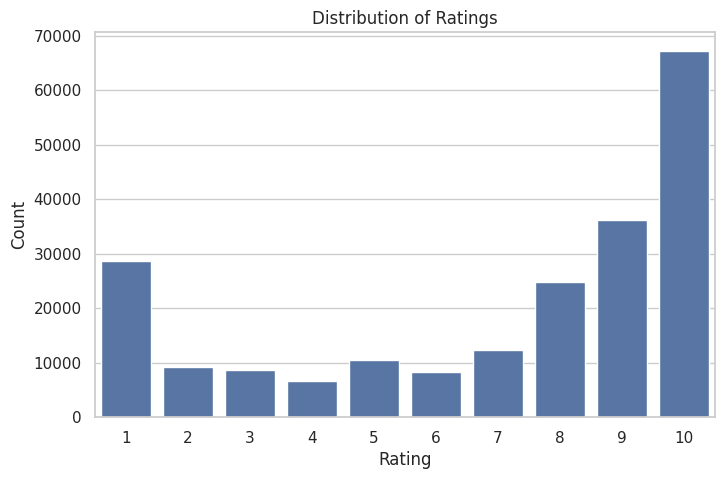

In [19]:
# ==========================================================
# Rating Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=uci_df,
    x="rating"
)

plt.title("Distribution of Ratings")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

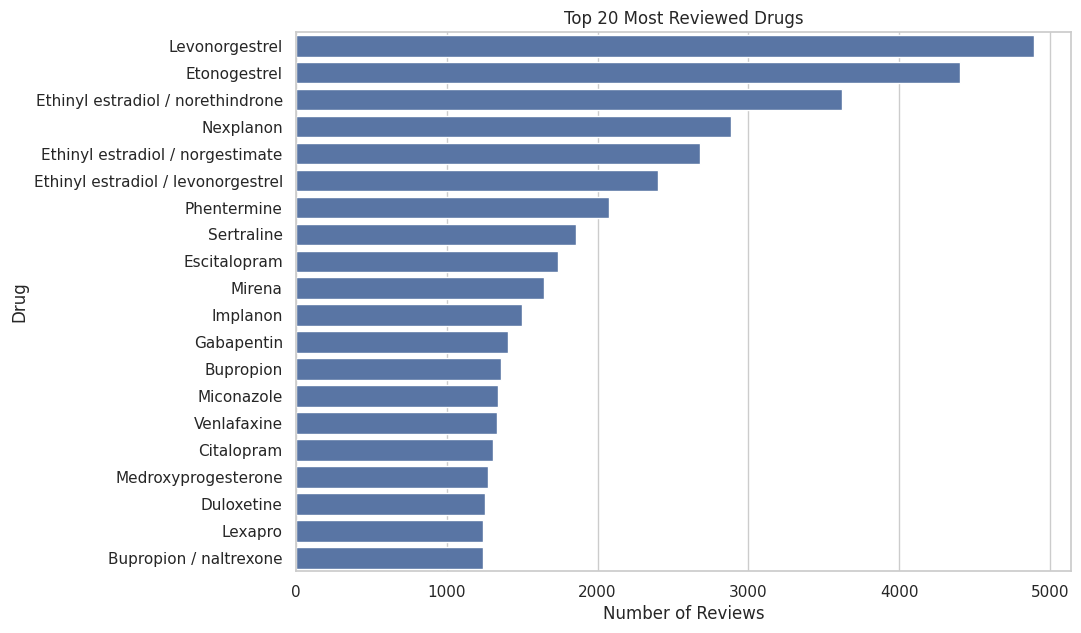

In [20]:
# ==========================================================
# Top 20 Drugs
# ==========================================================

top_drugs = (
    uci_df["drugName"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_drugs.values,
    y=top_drugs.index
)

plt.title("Top 20 Most Reviewed Drugs")

plt.xlabel("Number of Reviews")

plt.ylabel("Drug")

plt.show()

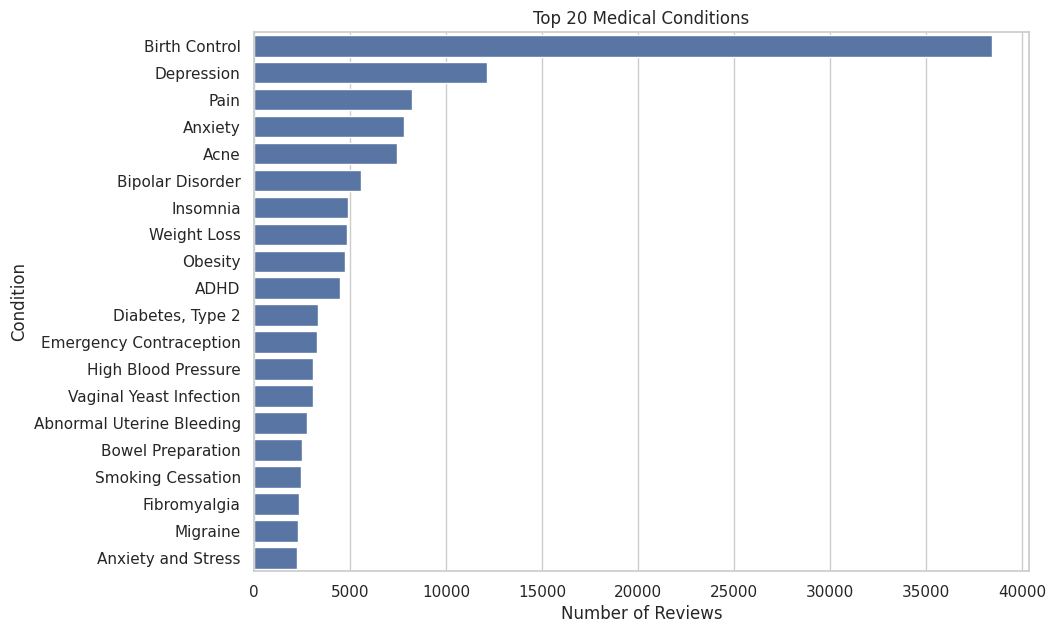

In [21]:
# ==========================================================
# Top 20 Conditions
# ==========================================================

top_conditions = (
    uci_df["condition"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index
)

plt.title("Top 20 Medical Conditions")

plt.xlabel("Number of Reviews")

plt.ylabel("Condition")

plt.show()

In [22]:
# ==========================================================
# Review Length
# ==========================================================

uci_df["review_length"] = (
    uci_df["review"]
    .astype(str)
    .str.split()
    .str.len()
)

uci_df["review_length"].describe()

,review_length
count,212357.000000
mean,84.774064
std,44.879035
min,1.000000
25%,48.000000
50%,84.000000
75%,126.000000
max,1894.000000


In [23]:
# Roughly estimate token count from word count (BERT tokenizes into more
# pieces than words, so this is a lower bound — real token count is higher)
long_reviews = (uci_df["review_length"] > 400).sum()
pct_long = long_reviews / len(uci_df) * 100

print(f"Reviews over ~400 words: {long_reviews} ({pct_long:.2f}%)")
print(uci_df["review_length"].describe())

Reviews over ~400 words: 65 (0.03%)
count    212357.000000
mean         84.774064
std          44.879035
min           1.000000
25%          48.000000
50%          84.000000
75%         126.000000
max        1894.000000
Name: review_length, dtype: float64


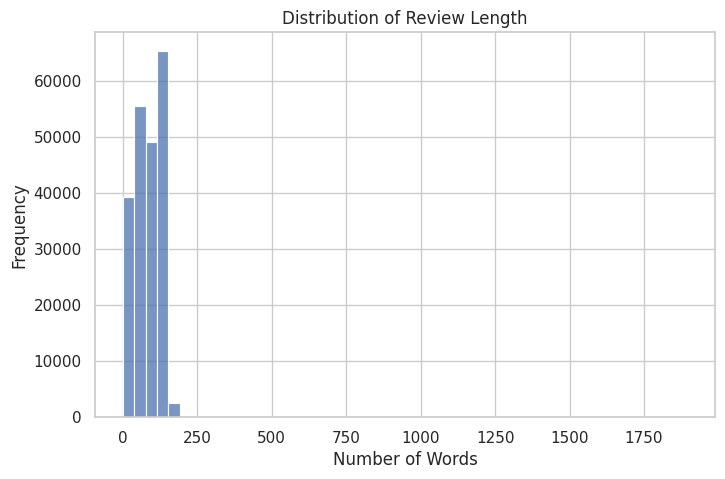

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    uci_df["review_length"],
    bins=50
)

plt.title("Distribution of Review Length")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [25]:
# ==========================================================
# Longest Reviews
# ==========================================================

uci_df.nlargest(
    5,
    "review_length"
)[
    [
        "drugName",
        "condition",
        "review_length",
        "review"
    ]
]

,drugName,condition,review_length,review
74665,Venlafaxine,Migraine,1894,"""Two and a half months ago I was prescribed Ve..."
137908,Prozac,Obsessive Compulsive Disorder,1162,"""I don’t find a lot of positive stories about ..."
203617,Fluoxetine,Obsessive Compulsive Disorder,1162,"""I don’t find a lot of positive stories about ..."
139538,Copper,Birth Control,1107,"""My Complicated experience with the insertion ..."
42673,Levonorgestrel,Emergency Contraception,1103,"""Okay ladies, I have decided to share my exper..."


In [26]:
# ==========================================================
# Shortest Reviews
# ==========================================================

uci_df.nsmallest(
    5,
    "review_length"
)[
    [
        "drugName",
        "condition",
        "review_length",
        "review"
    ]
]

,drugName,condition,review_length,review
365,Ledipasvir / sofosbuvir,Hepatitis C,1,"""Headache"""
1072,Amphetamine / dextroamphetamine,ADHD,1,"""Great"""
1884,Alesse,Birth Control,1,"""Awesome"""
2065,Zegerid,GERD,1,"""expensive"""
2160,Rivaroxaban,Deep Vein Thrombosis,1,"""Good"""


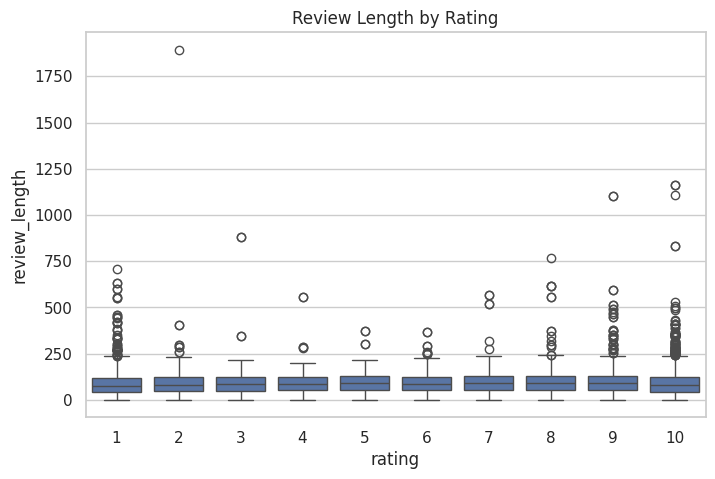

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=uci_df,
    x="rating",
    y="review_length"
)

plt.title("Review Length by Rating")

plt.show()

In [28]:
uci_df.describe(include="all")

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length
count,212357.000000,212357,212357,212357,212357.000000,212357,212357.00000,212357.000000
unique,NaN,3642,818,127269,NaN,3579,NaN,NaN
top,NaN,Levonorgestrel,Birth Control,"""Good""",NaN,2016-03-01,NaN,NaN
freq,NaN,4896,38436,39,NaN,185,NaN,NaN
mean,116162.483596,NaN,NaN,NaN,6.992353,NaN,28.18062,84.774064
std,66960.807160,NaN,NaN,NaN,3.276089,NaN,36.46570,44.879035
min,0.000000,NaN,NaN,NaN,1.000000,NaN,0.00000,1.000000
25%,58318.000000,NaN,NaN,NaN,5.000000,NaN,6.00000,48.000000
50%,116037.000000,NaN,NaN,NaN,8.000000,NaN,16.00000,84.000000
75%,174068.000000,NaN,NaN,NaN,10.000000,NaN,37.00000,126.000000


In [29]:
# ==========================================================
# Preserve Raw Dataset
# ==========================================================

uci_raw = uci_df.copy()

print("Raw dataset backup created successfully.")

Raw dataset backup created successfully.


#🟩 PHASE 4 — Text Cleaning & Preprocessing
🎯 Objective

Clean patient reviews while preserving medically meaningful information (especially negations like "no", "not", "never").

In [30]:
# ==========================================================
# Text Cleaning Libraries
# ==========================================================

import re
import string
import contractions

In [31]:
# ==========================================================
# Text Cleaning Function
# ==========================================================

def clean_review(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove emojis / non-ASCII characters
    text = text.encode("ascii", "ignore").decode()

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [32]:
# ==========================================================
# Apply Text Cleaning
# ==========================================================

uci_df["clean_review"] = uci_df["review"].apply(clean_review)

In [33]:
# ==========================================================
# Compare Original and Cleaned Reviews
# ==========================================================

uci_df[
    ["review", "clean_review"]
].sample(10, random_state=42)

,review,clean_review
163084,"""I recently had injection number 5 out of a si...",i recently had injection number out of a six m...
117835,"""I started out at 201lb on 6/25/17. I get the ...",i started out at lb on i get the generic pills...
148179,"""I'm taking it for 5 weeks now. Maybe makes me...",i am taking it for weeks now maybe makes me fe...
168903,"""My wife uses Xanax. She is bipolar II. She ha...",my wife uses xanax she is bipolar ii she has a...
169975,"""Worked perfectly""",worked perfectly
129865,"""This is so amazing, I had a severe outbreak a...",this is so amazing i had a severe outbreak and...
128615,"""I was started on 40mg for 2 weeks..I felt lik...",i was started on mg for weeksi felt like someo...
46975,"""I have taken Niaspan 2000 mg for several year...",i have taken niaspan mg for several years now ...
136542,"""Provigil works great for me, at 200 mg once i...",provigil works great for me at mg once in the ...
36114,"""Had ankylosing spondylitis and psoriasis badl...",had ankylosing spondylitis and psoriasis badly...


In [34]:
# ==========================================================
# Empty Reviews After Cleaning
# ==========================================================

empty_reviews = (
    uci_df["clean_review"]
    .str.len()
    .eq(0)
    .sum()
)

print("Empty Reviews:", empty_reviews)

Empty Reviews: 4


In [35]:
# ==========================================================
# Review Length After Cleaning
# ==========================================================

uci_df["clean_length"] = (
    uci_df["clean_review"]
    .str.split()
    .str.len()
)

uci_df["clean_length"].describe()

,clean_length
count,212357.000000
mean,84.232655
std,44.738138
min,0.000000
25%,48.000000
50%,84.000000
75%,125.000000
max,1909.000000


In [36]:
# ==========================================================
# Save Cleaned Dataset
# ==========================================================

uci_clean = uci_df.copy()

#🟩 Phase 5 — Dictionary

In [37]:
# ==========================================================
# PHASE 5 - ADE Resources
# ==========================================================

import re
import string
import pandas as pd
import numpy as np

In [38]:
from google.colab import files

uploaded = files.upload()

Saving patient_phrases.csv to patient_phrases.csv
Saving normalization.csv to normalization.csv
Saving ade_terms.txt to ade_terms.txt


In [39]:
# ==========================================================
# Load ADE Lexicon
# ==========================================================

with open("ade_terms.txt", "r", encoding="utf-8") as f:
    ADE_TERMS = [
        line.strip().lower()
        for line in f
        if line.strip() and not line.startswith("#")
    ]

print(f"Loaded {len(ADE_TERMS)} ADE terms.")
print(ADE_TERMS[:10])

Loaded 855 ADE terms.
['nausea', 'vomiting', 'diarrhea', 'constipation', 'abdominal pain', 'abdominal cramping', 'dyspepsia', 'bloating', 'flatulence', 'heartburn']


In [40]:
# ==========================================================
# Load Consumer Language Normalization Dictionary
# ==========================================================

normalization_df = (
    pd.read_csv("normalization.csv")
    .drop_duplicates()
)

normalization_df["consumer_term"] = (
    normalization_df["consumer_term"]
    .str.lower()
    .str.strip()
)

normalization_df["medical_term"] = (
    normalization_df["medical_term"]
    .str.lower()
    .str.strip()
)

normalization_dict = dict(
    zip(
        normalization_df["consumer_term"],
        normalization_df["medical_term"]
    )
)

print(f"Loaded {len(normalization_dict)} normalization mappings.")

Loaded 323 normalization mappings.


In [41]:
# ==========================================================
# Load Patient Phrase Dictionary
# ==========================================================

phrases_df = (
    pd.read_csv("patient_phrases.csv")
    .drop_duplicates()
)

phrases_df["phrase"] = (
    phrases_df["phrase"]
    .str.lower()
    .str.strip()
)

phrases_df["normalized"] = (
    phrases_df["normalized"]
    .str.lower()
    .str.strip()
)

PATIENT_PHRASES = dict(
    zip(
        phrases_df["phrase"],
        phrases_df["normalized"]
    )
)

print(f"Loaded {len(PATIENT_PHRASES)} patient phrases.")

Loaded 270 patient phrases.


In [42]:
# ==========================================================
# Compile ADE Search Patterns
# ==========================================================

ADE_PATTERNS = sorted(
    ADE_TERMS,
    key=len,
    reverse=True
)

print("Compiled", len(ADE_PATTERNS), "ADE search patterns.")

Compiled 855 ADE search patterns.


In [43]:
print("\nFirst 10 ADE Terms:")
print(ADE_TERMS[:10])

print("\nSample Normalization Dictionary:")
print(dict(list(normalization_dict.items())[:10]))

print("\nSample Patient Phrases:")
print(dict(list(PATIENT_PHRASES.items())[:10]))


First 10 ADE Terms:
['nausea', 'vomiting', 'diarrhea', 'constipation', 'abdominal pain', 'abdominal cramping', 'dyspepsia', 'bloating', 'flatulence', 'heartburn']

Sample Normalization Dictionary:
{'throwing up': 'vomiting', 'throwing up a lot': 'vomiting', 'puking': 'vomiting', 'feeling sick to my stomach': 'nausea', 'blurred eyesight': 'blurred vision', 'queasy': 'nausea', 'upset stomach': 'dyspepsia', 'stomach ache': 'abdominal pain', 'tummy pain': 'abdominal pain', 'gassy': 'flatulence'}

Sample Patient Phrases:
{'heart racing': 'palpitations', 'racing heart': 'palpitations', 'pounding heart': 'palpitations', 'heart pounding': 'palpitations', 'heart skipping beats': 'palpitations', 'heart fluttering': 'palpitations', 'heart flutters': 'palpitations', 'thumping in my chest': 'palpitations', 'stomach ache': 'abdominal pain', 'tummy pain': 'abdominal pain'}


In [44]:
# ==========================================================
# Validate Resource Consistency
# ==========================================================

missing_normalization = sorted(
    set(normalization_dict.values()) - set(ADE_TERMS)
)

missing_phrases = sorted(
    set(PATIENT_PHRASES.values()) - set(ADE_TERMS)
)

print("Missing normalization terms:", len(missing_normalization))
print("Missing patient phrase terms:", len(missing_phrases))

if missing_normalization:
    print("\nNormalization terms not in ADE lexicon:")
    print(missing_normalization[:20])

if missing_phrases:
    print("\nPatient phrase terms not in ADE lexicon:")
    print(missing_phrases[:20])

Missing normalization terms: 0
Missing patient phrase terms: 0


#🟩 PHASE 6 — Hybrid ADE Extraction

In [45]:
# ==========================================================
# Install Required Packages
# ==========================================================

!pip -q install transformers
!pip -q install sentencepiece
!pip -q install accelerate

In [46]:
import re
import torch
import pandas as pd

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForTokenClassification
)

In [47]:
# ==========================================================
# Reproducibility
# ==========================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


In [48]:
# ==========================================================
# GPU / CPU
# ==========================================================

device = 0 if torch.cuda.is_available() else -1

print("Device:", "GPU" if device == 0 else "CPU")

Device: GPU


##NER Model Loading

In [49]:
MODEL_NAME = "abhibisht89/spanbert-large-cased-finetuned-ade_corpus_v2"

In [50]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/356 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [51]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.33GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [52]:
ner_pipeline = pipeline(

    task="token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple",
    device=device

)

In [53]:
print(model.config.id2label)

{0: 'O', 1: 'B-DRUG', 2: 'I-DRUG', 3: 'B-ADR', 4: 'I-ADR'}


In [54]:
sample_review = """
I had severe headache,
constant vomiting,
heart racing,
blurred vision
after taking the medicine.
"""

prediction = ner_pipeline(sample_review)

prediction

[{'entity_group': 'ADR',
  'score': np.float32(0.8415358),
  'word': 'severe headache',
  'start': 7,
  'end': 22},
 {'entity_group': 'ADR',
  'score': np.float32(0.9036539),
  'word': 'constant vomiting',
  'start': 24,
  'end': 41},
 {'entity_group': 'ADR',
  'score': np.float32(0.9615965),
  'word': 'heart racing',
  'start': 43,
  'end': 55},
 {'entity_group': 'ADR',
  'score': np.float32(0.9623717),
  'word': 'blurred vision',
  'start': 57,
  'end': 71}]

##Normalize Consumer Language

In [55]:
# ==========================================================
# Consumer Language Normalization
# ==========================================================

def normalize_review(review):

    review = str(review).lower()

    for consumer, medical in normalization_dict.items():

        pattern = r"\b" + re.escape(consumer) + r"\b"

        review = re.sub(pattern, medical, review)

    return review

## Rule-Based Dictionary Matching



In [56]:
# ==========================================================
# Rule-Based ADE Extraction
# ==========================================================

def dictionary_match(review):

    review = normalize_review(review)

    matches = []

    for term in ADE_PATTERNS:

        pattern = r"\b" + re.escape(term) + r"\b"

        if re.search(pattern, review):

            matches.append(term)

    return sorted(set(matches))

In [57]:
dictionary_match(
    "I was throwing up with heart racing and blurred eyesight."
)

['blurred vision', 'palpitations', 'vomiting']

## Patient Phrase Matching

In [58]:
# ==========================================================
# Patient Phrase Matching
# ==========================================================

def phrase_match(review):

    review = review.lower()

    entities = []

    for phrase, normalized in PATIENT_PHRASES.items():

        pattern = r"\b" + re.escape(phrase) + r"\b"

        if re.search(pattern, review):

            entities.append(normalized)

    return sorted(set(entities))

In [59]:
phrase_match(
    "My room spinning and heart racing became unbearable."
)

['palpitations', 'vertigo']

## NER Extraction (Normalized)

In [60]:
# ==========================================================
# NER Extraction
# ==========================================================

SEVERITY_WORDS = {
    "mild",
    "moderate",
    "severe",
    "constant",
    "persistent",
    "terrible",
    "extreme",
    "chronic"
}


def extract_ner_entities(review):

    review = str(review)

    # ------------------------------------------------------
    # Truncate using the tokenizer (safe for BERT)
    # ------------------------------------------------------

    encoded = tokenizer(
        review,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    review = tokenizer.decode(
        encoded["input_ids"][0],
        skip_special_tokens=True
    )

    # ------------------------------------------------------

    predictions = ner_pipeline(review)

    entities = []

    for pred in predictions:

        if pred["entity_group"] != "ADR":
            continue

        entity = pred["word"].lower().strip()

        # Normalize consumer expressions
        entity = normalization_dict.get(entity, entity)

        # Remove severity modifiers
        words = entity.split()

        words = [
            w
            for w in words
            if w not in SEVERITY_WORDS
        ]

        entity = " ".join(words)

        # Normalize again
        entity = normalization_dict.get(entity, entity)

        entities.append({

            "entity": entity,

            "confidence": float(pred["score"])

        })

    return entities

In [61]:
extract_ner_entities(sample_review)

[{'entity': 'headache', 'confidence': 0.8415358066558838},
 {'entity': 'vomiting', 'confidence': 0.9036539196968079},
 {'entity': 'palpitations', 'confidence': 0.9615964889526367},
 {'entity': 'blurred vision', 'confidence': 0.9623717069625854}]

#🟩 PHASE 6.1 — Hybrid ADE Merge

In [62]:
# ==========================================================
# Hybrid ADE Extraction
# ==========================================================

RULE_CONFIDENCE = 0.95
PHRASE_CONFIDENCE = 0.90

def hybrid_extract(review):

    rule_entities = dictionary_match(review)
    phrase_entities = phrase_match(review)
    ner_results = extract_ner_entities(review)

    merged = {}

    # -----------------------------
    # Rule-Based
    # -----------------------------
    for entity in rule_entities:

        merged[entity] = {
            "entity": entity,
            "confidence": RULE_CONFIDENCE,
            "sources": {"rule"}
        }

    # -----------------------------
    # Phrase Matching
    # -----------------------------
    for entity in phrase_entities:

        if entity not in merged:

            merged[entity] = {
                "entity": entity,
                "confidence": PHRASE_CONFIDENCE,
                "sources": {"phrase"}
            }

        else:

            merged[entity]["sources"].add("phrase")

            merged[entity]["confidence"] = max(
                merged[entity]["confidence"],
                PHRASE_CONFIDENCE
            )

    # -----------------------------
    # NER
    # -----------------------------
    for item in ner_results:

        entity = item["entity"]
        confidence = item["confidence"]

        if entity not in merged:

            merged[entity] = {
                "entity": entity,
                "confidence": confidence,
                "sources": {"ner"}
            }

        else:

            merged[entity]["sources"].add("ner")

            merged[entity]["confidence"] = max(
                merged[entity]["confidence"],
                confidence
            )

    return list(merged.values())

In [63]:
sample_review = """
I had severe headache,
constant vomiting,
heart racing,
blurred vision
after taking this medicine.
"""

hybrid_extract(sample_review)

[{'entity': 'blurred vision',
  'confidence': 0.9638804793357849,
  'sources': {'ner', 'rule'}},
 {'entity': 'headache', 'confidence': 0.95, 'sources': {'ner', 'rule'}},
 {'entity': 'palpitations',
  'confidence': 0.9627846479415894,
  'sources': {'ner', 'phrase', 'rule'}},
 {'entity': 'vomiting', 'confidence': 0.95, 'sources': {'ner', 'rule'}}]

In [64]:
# ==========================================================
# Negation Detection
# ==========================================================

NEGATION_WORDS = {

    "no",
    "not",
    "never",
    "none",
    "without",
    "didn't",
    "didnt",
    "don't",
    "dont",
    "doesn't",
    "doesnt",
    "wasn't",
    "wasnt",
    "weren't",
    "werent"

}

In [65]:
CLAUSE_BREAK = r"[.,;!?]|\bbut\b|\bhowever\b|\balthough\b|\byet\b"

def remove_negated_entities(review, entities):
    review = review.lower()
    filtered = []
    for item in entities:
        entity = item["entity"]
        pattern = (
            r"(?:" + "|".join(map(re.escape, NEGATION_WORDS)) + r")"
            r"(?:(?!" + CLAUSE_BREAK + r").){0,25}?"
            + re.escape(entity)
        )
        if re.search(pattern, review):
            continue
        filtered.append(item)
    return filtered

In [66]:
review = """ I had no headache, but experienced vomiting and blurred vision."""

entities = hybrid_extract(review)
remove_negated_entities(review, entities)

[{'entity': 'blurred vision',
  'confidence': 0.9611603021621704,
  'sources': {'ner', 'rule'}},
 {'entity': 'vomiting',
  'confidence': 0.9643735289573669,
  'sources': {'ner', 'rule'}}]

#🟩 PHASE 6.2 – Severity Detection
Goal : Identify severity modifiers such as:

mild headache,
severe nausea,
unbearable pain,
terrible dizziness

We'll assign a severity level (1–5) to each extracted ADE.

##Severity Dictionary

In [67]:
# ==========================================================
# Severity Detection
# ==========================================================

SEVERITY_MAP = {

    "mild": 1,
    "slight": 1,
    "minor": 1,
    "moderate": 2,
    "bad": 3,
    "severe": 4,
    "persistent": 4,
    "constant": 4,
    "terrible": 5,
    "extreme": 5,
    "unbearable": 5,
    "worst": 5
}

##Severity Detection Function

In [68]:
# ==========================================================
# Severity Detection (Nearest Modifier)
# ==========================================================

import re
WINDOW_SIZE = 5

def detect_severity(review, entities):
    review = review.lower()

    # Tokenize while removing punctuation
    words = re.findall(r"\b[\w'-]+\b", review)

    for item in entities:
        entity = item["entity"].lower()

        severity_score = 0
        severity_word = None

        entity_tokens = re.findall(r"\b[\w'-]+\b", entity)

        # Find ADE position
        entity_pos = None

        for i in range(len(words) - len(entity_tokens) + 1):
            if words[i:i+len(entity_tokens)] == entity_tokens:

                entity_pos = i
                break

        if entity_pos is None:
            item["severity_score"] = 0
            item["severity_word"] = None
            continue

        # Local context window
        start = max(0, entity_pos - WINDOW_SIZE)
        end = min(len(words), entity_pos + len(entity_tokens) + WINDOW_SIZE)

        context = words[start:end]
        best_distance = float("inf")

        for sev_word, score in SEVERITY_MAP.items():
            sev_tokens = re.findall(
                r"\b[\w'-]+\b",
                sev_word.lower()
            )

            for j in range(len(context) - len(sev_tokens) + 1):

                if context[j:j+len(sev_tokens)] == sev_tokens:
                    sev_pos = start + j
                    distance = abs(sev_pos - entity_pos)

                    # Keep nearest severity modifier
                    if distance < best_distance:

                        best_distance = distance
                        severity_score = score
                        severity_word = sev_word

        item["severity_score"] = severity_score
        item["severity_word"] = severity_word

    return entities

In [69]:
review = """
I had severe headache,
terrible vomiting,
and mild dizziness.
"""

entities = hybrid_extract(review)
entities = remove_negated_entities(review, entities)
detect_severity(review, entities)

[{'entity': 'dizziness',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 1,
  'severity_word': 'mild'},
 {'entity': 'headache',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'severe'},
 {'entity': 'vomiting',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 5,
  'severity_word': 'terrible'}]

In [70]:
review = """
The headache was severe.
My vomiting became terrible.
I had mild dizziness.
"""

entities = hybrid_extract(review)

entities = remove_negated_entities(review, entities)

detect_severity(review, entities)

[{'entity': 'dizziness',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 1,
  'severity_word': 'mild'},
 {'entity': 'headache',
  'confidence': 0.95,
  'sources': {'rule'},
  'severity_score': 4,
  'severity_word': 'severe'},
 {'entity': 'vomiting',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'severe'},
 {'entity': '',
  'confidence': 0.4947395622730255,
  'sources': {'ner'},
  'severity_score': 4,
  'severity_word': 'severe'}]

#🟩 PHASE 6.3 – Frequency Detection
Goal : Capture how often an ADE occurs.

Examples- always nauseous, frequently vomiting, occasionally dizzy

##Frequency Dictionary

In [71]:
# ==========================================================
# Frequency Detection
# ==========================================================

FREQUENCY_MAP = {
    "once":1,
    "occasionally":2,
    "sometimes":2,
    "often":3,
    "frequently":4,
    "daily":5,
    "always":5,
    "constantly":5
}

##Frequency Detection Function

In [72]:
# ==========================================================
# Frequency Detection (Nearest Modifier)
# ==========================================================

import re

WINDOW_SIZE = 5

def detect_frequency(review, entities):

    review = review.lower()

    # Tokenize while removing punctuation
    words = re.findall(r"\b[\w'-]+\b", review)

    for item in entities:

        entity = item["entity"].lower()

        frequency_score = 0
        frequency_word = None

        entity_tokens = re.findall(r"\b[\w'-]+\b", entity)

        # Find the ADE position
        entity_pos = None

        for i in range(len(words) - len(entity_tokens) + 1):

            if words[i:i+len(entity_tokens)] == entity_tokens:

                entity_pos = i
                break

        if entity_pos is None:

            item["frequency_score"] = 0
            item["frequency_word"] = None
            continue

        # Local context window
        start = max(0, entity_pos - WINDOW_SIZE)
        end = min(len(words), entity_pos + len(entity_tokens) + WINDOW_SIZE)

        context = words[start:end]

        best_distance = float("inf")

        for freq_word, score in FREQUENCY_MAP.items():

            freq_tokens = re.findall(
                r"\b[\w'-]+\b",
                freq_word.lower()
            )

            for j in range(len(context) - len(freq_tokens) + 1):

                if context[j:j+len(freq_tokens)] == freq_tokens:

                    # Position of frequency word in full review
                    freq_pos = start + j

                    distance = abs(freq_pos - entity_pos)

                    # Keep the nearest modifier
                    if distance < best_distance:

                        best_distance = distance
                        frequency_score = score
                        frequency_word = freq_word

        item["frequency_score"] = frequency_score
        item["frequency_word"] = frequency_word

    return entities

In [73]:
review = """
I was always nauseous
and frequently vomiting.
"""

entities = hybrid_extract(review)

entities = remove_negated_entities(review, entities)

entities = detect_severity(review, entities)

detect_frequency(review, entities)

[{'entity': 'vomiting',
  'confidence': 0.9558365345001221,
  'sources': {'ner', 'rule'},
  'severity_score': 0,
  'severity_word': None,
  'frequency_score': 4,
  'frequency_word': 'frequently'},
 {'entity': 'nauseous',
  'confidence': 0.9449360370635986,
  'sources': {'ner'},
  'severity_score': 0,
  'severity_word': None,
  'frequency_score': 5,
  'frequency_word': 'always'}]

In [74]:
review = """
I frequently experienced vomiting.
My headache happens daily.
I was always dizzy.
"""

entities = hybrid_extract(review)
entities = remove_negated_entities(review, entities)
entities = detect_severity(review, entities)
detect_frequency(review, entities)

[{'entity': 'headache',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 0,
  'severity_word': None,
  'frequency_score': 5,
  'frequency_word': 'daily'},
 {'entity': 'vomiting',
  'confidence': 0.9592190980911255,
  'sources': {'ner', 'rule'},
  'severity_score': 0,
  'severity_word': None,
  'frequency_score': 4,
  'frequency_word': 'frequently'},
 {'entity': 'dizzy',
  'confidence': 0.5167356729507446,
  'sources': {'ner'},
  'severity_score': 0,
  'severity_word': None,
  'frequency_score': 5,
  'frequency_word': 'always'}]

#🟩 PHASE 6.4 – Silver Label Generation

Now we'll decide whether an extracted ADE should become a silver label.

We'll use a threshold:

1. ≥ 0.70 → ADE present (Silver Label = 1)
2. < 0.70 → ADE absent (Silver Label = 0)

##6.4.1 – Generate Silver Labels

In [75]:
# ==========================================================
# Silver Label Generation
# ==========================================================

CONFIDENCE_THRESHOLD = 0.70

def generate_silver_labels(entities):

    for item in entities:

        item["silver_label"] = int(
            item["confidence"] >= CONFIDENCE_THRESHOLD
        )

    return entities

In [76]:
review = """
I had severe headache.
I frequently experienced vomiting.
"""

entities = hybrid_extract(review)

entities = remove_negated_entities(review, entities)

entities = detect_severity(review, entities)

entities = detect_frequency(review, entities)

entities = generate_silver_labels(entities)

entities

[{'entity': 'headache',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'severe',
  'frequency_score': 4,
  'frequency_word': 'frequently',
  'silver_label': 1},
 {'entity': 'vomiting',
  'confidence': 0.9628041982650757,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'severe',
  'frequency_score': 4,
  'frequency_word': 'frequently',
  'silver_label': 1}]

#🟩 PHASE 6.5 — Complete Review Processing Pipeline

In [77]:
# ==========================================================
# Complete Hybrid ADE Pipeline
# ==========================================================

def process_review(review):

    # Step 1
    entities = hybrid_extract(review)

    # Step 2
    entities = remove_negated_entities(review, entities)

    # Step 3
    entities = detect_severity(review, entities)

    # Step 4
    entities = detect_frequency(review, entities)

    # Step 5
    entities = generate_silver_labels(entities)

    return entities

In [78]:
sample_review = """
After taking this medicine, I had severe headache, heart racing,
constant vomiting, and blurred vision.
"""

process_review(sample_review)

[{'entity': 'blurred vision',
  'confidence': 0.9642795324325562,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'constant',
  'frequency_score': 0,
  'frequency_word': None,
  'silver_label': 1},
 {'entity': 'headache',
  'confidence': 0.95,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'severe',
  'frequency_score': 0,
  'frequency_word': None,
  'silver_label': 1},
 {'entity': 'palpitations',
  'confidence': 0.9619786739349365,
  'sources': {'ner', 'phrase', 'rule'},
  'severity_score': 0,
  'severity_word': None,
  'frequency_score': 0,
  'frequency_word': None,
  'silver_label': 1},
 {'entity': 'vomiting',
  'confidence': 0.9521334767341614,
  'sources': {'ner', 'rule'},
  'severity_score': 4,
  'severity_word': 'constant',
  'frequency_score': 0,
  'frequency_word': None,
  'silver_label': 1}]

In [79]:
# ==========================================================
# Display Results as DataFrame
# ==========================================================

def display_review_results(review):

    entities = process_review(review)

    df = pd.DataFrame(entities)

    return df

In [80]:
display_review_results(sample_review)

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,entity,confidence,sources,severity_score,severity_word,frequency_score,frequency_word,silver_label
0,blurred vision,0.964280,"{rule, ner}",4,constant,0,None,1
1,headache,0.950000,"{rule, ner}",4,severe,0,None,1
2,palpitations,0.961979,"{rule, ner, phrase}",0,None,0,None,1
3,vomiting,0.952133,"{rule, ner}",4,constant,0,None,1


#🟩 PHASE 7 – Apply the Hybrid Pipeline to the Dataset

In [81]:
print(uci_dataset)

DatasetDict({
    train: Dataset({
        features: ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 161297
    })
    test: Dataset({
        features: ['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount'],
        num_rows: 53766
    })
})


In [82]:
df = uci_dataset["train"].to_pandas()

In [83]:
print(df.shape)

df.head()

(161297, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


In [84]:
print(df.columns.tolist())

['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date', 'usefulCount']


In [85]:
for i in range(20):

    review = df.loc[i, "review"]

    if "headache" in review.lower() \
       or "nausea" in review.lower() \
       or "vomiting" in review.lower() \
       or "dizzy" in review.lower() \
       or "rash" in review.lower():

        print("Index:", i)
        print(review)
        print("-"*80)

Index: 5
"2nd day on 5mg started to work with rock hard erections however experianced headache, lower bowel preassure. 3rd day erections would wake me up & hurt! Leg/ankles aches   severe lower bowel preassure like you need to go #2 but can't! Enjoyed the initial rockhard erections but not at these side effects or $230 for months supply! I'm 50 & work out 3Xs a week. Not worth side effects!"
--------------------------------------------------------------------------------
Index: 10
"I have been on this medication almost two weeks, started out on 25mg and working my way up to 100mg, currently at 50mg. No headaches at all so far and I was having 2-3 crippling migraines a week. I have lost 5.2lbs so far but note I am really paying close attention to what I am eating, I have a lot of weight to lose and if weight loss is a side effect I want to help it along as much as I can.  Now, other side effects, they are there the word recall issues exist, the memory issues, the worst of it seems to be

In [86]:
display_review_results(df.loc[15, "review"])

,entity,confidence,sources,severity_score,severity_word,frequency_score,frequency_word,silver_label
0,constipation,0.95,"{rule, ner}",0,None,0,None,1
1,nausea,0.95,"{rule, ner}",4,severe,1,once,1
2,weight loss,0.95,{rule},0,None,0,None,1


##PHASE 7.1 – Create Review Feature Extraction

In [87]:
# ==========================================================
# Extract Features From One Review
# ==========================================================
def extract_review_features(review, condition):

    # Run complete ADE extraction pipeline
    entities = process_review(review)

    # Keep only valid ADEs
    positive_entities = [
        e for e in entities
        if e["silver_label"] == 1
    ]

    # ==========================================================
    # Indication Filtering
    # Remove the treated condition from extracted ADEs
    # ==========================================================

    condition = str(condition).lower().strip()

    positive_entities = [
        e for e in positive_entities
        if e["entity"].lower().strip() != condition
    ]

    # ==========================================================

    ade_entities = [
        e["entity"]
        for e in positive_entities
    ]

    confidences = [
        e["confidence"]
        for e in positive_entities
    ]

    severities = [
        e["severity_score"]
        for e in positive_entities
    ]

    frequencies = [
        e["frequency_score"]
        for e in positive_entities
    ]

    return {

        "ade_entities": ade_entities,
        "ade_count": len(ade_entities),
        "silver_label": int(len(ade_entities) > 0),
        "max_confidence": round(max(confidences), 3) if confidences else 0,
        "max_severity": max(severities) if severities else 0,
        "max_frequency": max(frequencies) if frequencies else 0

    }

##PHASE 7.2 – Test on One Review

In [88]:
sample_review = df.loc[15, "review"]
sample_condition = df.loc[15, "condition"]

extract_review_features(
    sample_review,
    sample_condition
)

{'ade_entities': ['constipation', 'nausea', 'weight loss'],
 'ade_count': 3,
 'silver_label': 1,
 'max_confidence': 0.95,
 'max_severity': 4,
 'max_frequency': 1}

###Test on 100 reviews

In [89]:
from tqdm.auto import tqdm

sample_df = df.sample(
    100,
    random_state=42
).copy()
results = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    results.append(

        extract_review_features(
            row["review"],
            row["condition"]
        )
    )

  0%|          | 0/100 [00:00<?, ?it/s]

In [90]:
features_df = pd.DataFrame(results)

features_df.head(30)

,ade_entities,ade_count,silver_label,max_confidence,max_severity,max_frequency
0,[jittery jumping out of your skin],1,1,0.888,0,0
1,[],0,0,0.000,0,0
2,"[hot flashes, mood swings, dermoid cyst, pooch...",5,1,0.953,4,5
3,"[diarrhea, headache, hives, hives all over, ba...",7,1,0.963,5,0
4,"[allergic reaction, itching]",2,1,0.950,0,0
5,[],0,0,0.000,0,0
6,[],0,0,0.000,0,0
7,[],0,0,0.000,0,0
8,"[stiffness, pain, local reaction]",3,1,0.950,0,2
9,[apnea],1,1,0.950,1,0


In [91]:
sample_df = sample_df.reset_index(drop=True)

sample_df = pd.concat(
    [sample_df, features_df],
    axis=1
)

sample_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,ade_entities,ade_count,silver_label,max_confidence,max_severity,max_frequency
0,127888,Phentermine,Weight Loss,"""I started taking Phentermine just a little ov...",10,2016-11-26,24,[jittery jumping out of your skin],1,1,0.888,0,0
1,197702,Desvenlafaxine,Depression,"""I have had depression for years due to situat...",10,2009-07-25,31,[],0,0,0.000,0,0
2,40759,Leuprolide,Endometriosis,"""I was actually surprised to learn I had stage...",8,2011-12-21,31,"[hot flashes, mood swings, dermoid cyst, pooch...",5,1,0.953,4,5
3,208098,Zyclara,Keratosis,"""Have used this for one week but began to have...",7,2013-01-20,17,"[diarrhea, headache, hives, hives all over, ba...",7,1,0.963,5,0
4,161657,Diphenhydramine,Allergic Reactions,"""Experienced an allergic reaction during dinne...",10,2015-04-11,20,"[allergic reaction, itching]",2,1,0.950,0,0


In [92]:
sample_df["silver_label"].value_counts()

,count
silver_label,
1,67
0,33


In [93]:
sample_df["silver_label"].value_counts(normalize=True)

,proportion
silver_label,
1,0.67
0,0.33


In [94]:
sample_df[
    sample_df["silver_label"] == 1
][
    [
        "review",
        "ade_entities",
        "ade_count"
    ]
].head(10)

,review,ade_entities,ade_count
0,"""I started taking Phentermine just a little ov...",[jittery jumping out of your skin],1
2,"""I was actually surprised to learn I had stage...","[hot flashes, mood swings, dermoid cyst, pooch...",5
3,"""Have used this for one week but began to have...","[diarrhea, headache, hives, hives all over, ba...",7
4,"""Experienced an allergic reaction during dinne...","[allergic reaction, itching]",2
8,"""I have been on Enbrel for 6 months - - after ...","[stiffness, pain, local reaction]",3
9,"""I couldn't stay asleep, tried Lunesta and Amb...",[apnea],1
10,"""Sadly, I have not had a good experience with ...","[diarrhea, ear infection, exhaustion, heart pa...",8
11,"""If you are new to taking this medication or a...","[yeast, vein pain]",2
12,"""I took the pill 8 hours after unprotected sex...",[hard cramps],1
14,"""Been on this medication for over 12 years. W...","[increased hunger, minor dizziness]",2


In [95]:
sample_df[
    sample_df["silver_label"] == 1
][
    [
        "drugName",
        "condition",
        "review",
        "ade_entities",
        "ade_count"
    ]
].head(10)

,drugName,condition,review,ade_entities,ade_count
0,Phentermine,Weight Loss,"""I started taking Phentermine just a little ov...",[jittery jumping out of your skin],1
2,Leuprolide,Endometriosis,"""I was actually surprised to learn I had stage...","[hot flashes, mood swings, dermoid cyst, pooch...",5
3,Zyclara,Keratosis,"""Have used this for one week but began to have...","[diarrhea, headache, hives, hives all over, ba...",7
4,Diphenhydramine,Allergic Reactions,"""Experienced an allergic reaction during dinne...","[allergic reaction, itching]",2
8,Etanercept,Rheumatoid Arthritis,"""I have been on Enbrel for 6 months - - after ...","[stiffness, pain, local reaction]",3
9,Silenor,Insomnia,"""I couldn't stay asleep, tried Lunesta and Amb...",[apnea],1
10,Augmentin,None,"""Sadly, I have not had a good experience with ...","[diarrhea, ear infection, exhaustion, heart pa...",8
11,Pradaxa,Prevention of Thromboembolism in Atrial Fibril...,"""If you are new to taking this medication or a...","[yeast, vein pain]",2
12,Levonorgestrel,Emergency Contraception,"""I took the pill 8 hours after unprotected sex...",[hard cramps],1
14,BuSpar,Anxiety,"""Been on this medication for over 12 years. W...","[increased hunger, minor dizziness]",2


In [96]:
sample_df[
    sample_df["silver_label"] == 0
][
    [
        "drugName",
        "condition",
        "review",
        "ade_entities"
    ]
].head(10)

,drugName,condition,review,ade_entities
1,Desvenlafaxine,Depression,"""I have had depression for years due to situat...",[]
5,Progesterone,Perimenopausal Symptoms,"""I take this medicine in conjunction with appl...",[]
6,Ethinyl estradiol / norethindrone,Birth Control,"""I wanted to give my input since most of these...",[]
7,Lansoprazole,Erosive Esophagitis,"""Expensive but really helps with little or no ...",[]
13,Implanon,Birth Control,"""I am 51 year old on my 2nd Implanon device; t...",[]
16,Lubiprostone,Irritable Bowel Syndrome,"""This is really working for me. I am taking 24...",[]
17,Atrovent,"COPD, Maintenance","""I like this inhaler except for the ridiculous...",[]
18,Belviq,Weight Loss,"""I just started belviq today I'm a 39 yr old d...",[]
21,Propofol,Anesthesia,"""Went for colonoscopy after 12 year delay. New...",[]
24,Adapalene / benzoyl peroxide,Acne,"""Last year I stared using this. I used it for ...",[]


###Applying on full dataset

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [99]:
from tqdm.auto import tqdm
import os
import pickle
import pandas as pd

# ==========================================================
# Checkpoint File
# ==========================================================

checkpoint_file = "/content/drive/MyDrive/ade_checkpoint.pkl"

results = []
failed = []

# ==========================================================
# Resume From Previous Checkpoint
# ==========================================================

start_idx = 0

if os.path.exists(checkpoint_file):

    with open(checkpoint_file, "rb") as f:
        checkpoint = pickle.load(f)

    results = checkpoint["results"]
    failed = checkpoint["failed"]

    start_idx = len(results)

    print(f"Resuming from review {start_idx}")

# ==========================================================
# Process Reviews
# ==========================================================

for idx, row in tqdm(
    df.iloc[start_idx:].iterrows(),
    total=len(df) - start_idx
):

    try:

        features = extract_review_features(
            row["review"],
            row["condition"]
        )

        results.append(features)

    except Exception as e:

        failed.append((idx, str(e)))

        results.append({

            "ade_entities": [],
            "ade_count": 0,
            "silver_label": 0,
            "max_confidence": 0,
            "max_severity": 0,
            "max_frequency": 0

        })

    # ==========================================================
    # Save Checkpoint Every 5000 Reviews
    # ==========================================================

    if len(results) % 5000 == 0:

        with open(checkpoint_file, "wb") as f:

            pickle.dump(
                {
                    "results": results,
                    "failed": failed
                },
                f
            )

        print(f"Checkpoint saved at {len(results)} reviews.")

# ==========================================================
# Save Final Checkpoint
# ==========================================================

with open(checkpoint_file, "wb") as f:

    pickle.dump(
        {
            "results": results,
            "failed": failed
        },
        f
    )

print("Final checkpoint saved.")

# ==========================================================
# Merge Features with Original Dataset
# ==========================================================

features_df = pd.DataFrame(results)

df = pd.concat(
    [
        df.reset_index(drop=True),
        features_df.reset_index(drop=True)
    ],
    axis=1
)

print("Feature extraction completed.")
print(df.head())

  0%|          | 0/161297 [00:00<?, ?it/s]

Checkpoint saved at 5000 reviews.
Checkpoint saved at 10000 reviews.
Checkpoint saved at 15000 reviews.
Checkpoint saved at 20000 reviews.
Checkpoint saved at 25000 reviews.
Checkpoint saved at 30000 reviews.
Checkpoint saved at 35000 reviews.
Checkpoint saved at 40000 reviews.
Checkpoint saved at 45000 reviews.
Checkpoint saved at 50000 reviews.
Checkpoint saved at 55000 reviews.
Checkpoint saved at 60000 reviews.
Checkpoint saved at 65000 reviews.
Checkpoint saved at 70000 reviews.
Checkpoint saved at 75000 reviews.
Checkpoint saved at 80000 reviews.
Checkpoint saved at 85000 reviews.
Checkpoint saved at 90000 reviews.
Checkpoint saved at 95000 reviews.
Checkpoint saved at 100000 reviews.
Checkpoint saved at 105000 reviews.
Checkpoint saved at 110000 reviews.
Checkpoint saved at 115000 reviews.
Checkpoint saved at 120000 reviews.
Checkpoint saved at 125000 reviews.
Checkpoint saved at 130000 reviews.
Checkpoint saved at 135000 reviews.
Checkpoint saved at 140000 reviews.
Checkpoint s

In [100]:
with open(checkpoint_file, "wb") as f:
    pickle.dump(
        {
            "results": results,
            "failed": failed
        },
        f
    )

print("Final checkpoint saved.")

Final checkpoint saved.


In [101]:
print("Total processed:", len(results))
print("Failed reviews:", len(failed))

failed[:10]

Total processed: 161297
Failed reviews: 0


[]

In [118]:
features_df = pd.DataFrame(results)

features_df.head()

,ade_entities,ade_count,silver_label,max_confidence,max_severity,max_frequency
0,[],0,0,0.000,0,0
1,"[cranky, ##ranky]",2,1,0.806,0,0
2,[brown discharge],1,1,0.920,0,5
3,[],0,0,0.000,0,0
4,[constipation],1,1,0.950,1,0


###Saving the csv file

In [102]:
output_file = "/content/drive/MyDrive/uci_hybrid_silver_dataset.csv"

df.to_csv(output_file, index=False)

print("Dataset saved successfully!")
print(output_file)

Dataset saved successfully!
/content/drive/MyDrive/uci_hybrid_silver_dataset.csv


#🟩 PHASE 8 – Sentiment Analysis of Drug Reviews
Goal : Assign each review-

Sentiment label (Positive / Negative)
Sentiment confidence score

These will become two new columns in your dataset.

In [103]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/uci_hybrid_silver_dataset.csv")

In [104]:
from transformers import pipeline
import torch
from tqdm.auto import tqdm

##Phase 8.1: Sentiment Model

In [105]:
sentiment_pipeline = pipeline(

    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=512

)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [107]:
review = df.loc[10, "review"]

sentiment_pipeline(review)

[{'label': 'positive', 'score': 0.6559222340583801}]

In [106]:
def predict_batch(reviews):

    outputs = sentiment_pipeline(
        reviews,
        batch_size=64
    )

    results = []

    for out in outputs:

        results.append({

            "sentiment": out["label"].capitalize(),

            "sentiment_score": round(out["score"], 3)

        })

    return results

##Phase 8.2: Sentiment Analysis with Batch + Checkpoint

In [108]:
from tqdm.auto import tqdm
import os
import pickle

checkpoint_file = "/content/drive/MyDrive/sentiment_checkpoint.pkl"

sentiment_results = []

# Resume if checkpoint exists
start_idx = 0

if os.path.exists(checkpoint_file):

    with open(checkpoint_file, "rb") as f:
        checkpoint = pickle.load(f)

    sentiment_results = checkpoint["results"]
    start_idx = len(sentiment_results)

    print(f"Resuming from review {start_idx}")


# Batch size
batch_size = 500


reviews = df["review"].tolist()


for start in tqdm(
    range(start_idx, len(reviews), batch_size),
    total=(len(reviews)-start_idx)//batch_size + 1
):

    batch_reviews = reviews[start:start+batch_size]


    try:

        batch_predictions = predict_batch(batch_reviews)

        sentiment_results.extend(batch_predictions)


    except Exception as e:

        print("Error in batch:", start, e)

        # add empty predictions for failed batch
        sentiment_results.extend(
            [
                {
                    "label": "ERROR",
                    "score": 0
                }
            ] * len(batch_reviews)
        )


    # SAVE CHECKPOINT EVERY 5000 REVIEWS

    if len(sentiment_results) % 5000 == 0:

        with open(checkpoint_file, "wb") as f:

            pickle.dump(
                {
                    "results": sentiment_results
                },
                f
            )

        print(
            f"Checkpoint saved at {len(sentiment_results)} reviews"
        )

  0%|          | 0/323 [00:00<?, ?it/s]

Checkpoint saved at 5000 reviews
Checkpoint saved at 10000 reviews
Checkpoint saved at 15000 reviews
Checkpoint saved at 20000 reviews
Checkpoint saved at 25000 reviews
Checkpoint saved at 30000 reviews
Checkpoint saved at 35000 reviews
Checkpoint saved at 40000 reviews
Checkpoint saved at 45000 reviews
Checkpoint saved at 50000 reviews
Checkpoint saved at 55000 reviews
Checkpoint saved at 60000 reviews
Checkpoint saved at 65000 reviews
Checkpoint saved at 70000 reviews
Checkpoint saved at 75000 reviews
Checkpoint saved at 80000 reviews
Checkpoint saved at 85000 reviews
Checkpoint saved at 90000 reviews
Checkpoint saved at 95000 reviews
Checkpoint saved at 100000 reviews
Checkpoint saved at 105000 reviews
Checkpoint saved at 110000 reviews
Checkpoint saved at 115000 reviews
Checkpoint saved at 120000 reviews
Checkpoint saved at 125000 reviews
Checkpoint saved at 130000 reviews
Checkpoint saved at 135000 reviews
Checkpoint saved at 140000 reviews
Checkpoint saved at 145000 reviews
Check

In [109]:
sentiment_df = pd.DataFrame(sentiment_results)

sentiment_df.head()

,sentiment,sentiment_score
0,Neutral,0.646
1,Neutral,0.435
2,Neutral,0.502
3,Positive,0.847
4,Positive,0.899


In [110]:
df = pd.concat(
    [
        df.reset_index(drop=True),
        sentiment_df.reset_index(drop=True)
    ],
    axis=1
)

In [111]:
df[[
    "review",
    "sentiment",
    "sentiment_score"
]].head()

,review,sentiment,sentiment_score
0,"""It has no side effect, I take it in combinati...",Neutral,0.646
1,"""My son is halfway through his fourth week of ...",Neutral,0.435
2,"""I used to take another oral contraceptive, wh...",Neutral,0.502
3,"""This is my first time using any form of birth...",Positive,0.847
4,"""Suboxone has completely turned my life around...",Positive,0.899


###Cleaning the'#'

In [112]:
import ast
import pandas as pd

def clean_entities(entity_list):

    if pd.isna(entity_list):
        return []

    if isinstance(entity_list, str):
        entity_list = ast.literal_eval(entity_list)

    cleaned = []

    for entity in entity_list:

        # Remove isolated WordPiece fragments
        if entity.startswith("##"):
            continue

        cleaned.append(entity)

    # Remove duplicates while preserving order
    return list(dict.fromkeys(cleaned))


df["ade_entities"] = df["ade_entities"].apply(clean_entities)

# Recalculate derived columns
df["ade_count"] = df["ade_entities"].apply(len)
df["silver_label"] = (df["ade_count"] > 0).astype(int)

In [113]:
df[
    df["ade_entities"].astype(str).str.contains("##")
].shape

(0, 15)

In [114]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,ade_entities,ade_count,silver_label,max_confidence,max_severity,max_frequency,sentiment,sentiment_score
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,[],0,0,0.000,0,0,Neutral,0.646
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,[cranky],1,1,0.806,0,0,Neutral,0.435
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,[brown discharge],1,1,0.920,0,5,Neutral,0.502
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,[],0,0,0.000,0,0,Positive,0.847
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,[constipation],1,1,0.950,1,0,Positive,0.899


In [115]:
df.shape

(161297, 15)

#SAVING THE FINAL DATASET

In [116]:
import pickle

final_path = "/content/drive/MyDrive/final_uci_drug_review_ADE_sentiment.pkl"

with open(final_path, "wb") as f:
    pickle.dump(df, f)

print("Dataset saved successfully!")

Dataset saved successfully!


In [117]:
csv_path = "/content/drive/MyDrive/final_uci_drug_review_ADE_sentiment.csv"

df.to_csv(
    csv_path,
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!
